In [77]:
import pandas as pd
import numpy as np
import cmdstanpy
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import arviz as az
import os, cmdstanpy
cmdstanpy.set_cmdstan_path(os.path.expanduser("~/cmdstan"))



In [78]:
montpelier_data = pd.read_csv("montpelier_parcels.csv")


In [79]:
filtered_montpelier_data = montpelier_data[montpelier_data['n_homes'] == 1]
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['acres'] > 0]
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['improvements_value'] > 0]

filtered_montpelier_data.head()
print(f"Mean house value: {filtered_montpelier_data['listed_real_value'].mean()}")
print(f"Mean in flood zone: {filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 1]['listed_real_value'].mean()}")
print(f"Mean out of flood zone: {filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 0]['listed_real_value'].mean()}")


Mean house value: 368476.0768721007
Mean in flood zone: 349221.0
Mean out of flood zone: 369842.65436479775


In [80]:
def viz_scatter(x_col, y_col, xlabel, ylabel, x_ticks=None, y_ticks=None, title=None):
    out_zone = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 0]
    in_zone = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 1]

    plt.figure(figsize=(7, 6))
    plt.scatter(out_zone[x_col], out_zone[y_col], color='lightgrey', edgecolors='k',
                linewidths=0.5, alpha=0.6,                                  # NEW: transparency
                label=f'Outside SFHA (n = {len(out_zone):,})')              # NEW: counts
    plt.scatter(in_zone[x_col], in_zone[y_col], color='tab:blue', edgecolors='k',
                linewidths=0.5,
                label=f'Inside SFHA (n = {len(in_zone):,})')                # NEW: counts
    plt.xlabel(xlabel, fontsize=13)                                         # NEW: font size
    plt.ylabel(ylabel, fontsize=13)
    plt.legend(title='Flood zone', fontsize=11, title_fontsize=11, loc='lower right')
    if title is not None:                                                   # NEW: title
        plt.title(title, fontsize=14)

    if x_ticks is not None:
        values, labels = x_ticks
        plt.xticks(np.log(values), labels)
    if y_ticks is not None:
        values, labels = y_ticks
        plt.yticks(np.log(values), labels)
    plt.tick_params(labelsize=11)                                           # NEW: tick font size

    ax = plt.gca()                                                          # NEW: remove top/right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

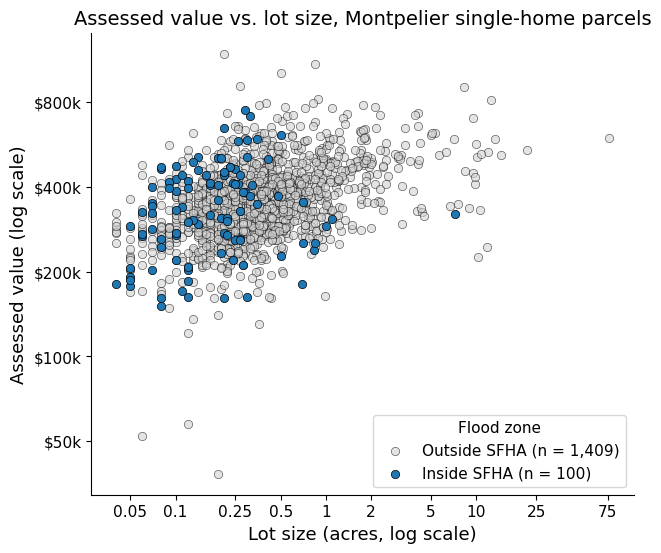

In [81]:
filtered_montpelier_data['log_acres'] = np.log(filtered_montpelier_data['acres'])
filtered_montpelier_data['log_value'] = np.log(filtered_montpelier_data['listed_real_value'])

acre_ticks = ([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25, 75],
              ['0.05', '0.1', '0.25', '0.5', '1', '2', '5', '10', '25', '75'])
dollar_ticks = ([50_000, 100_000, 200_000, 400_000, 800_000],
                ['$50k', '$100k', '$200k', '$400k', '$800k'])

viz_scatter('log_acres', 'log_value',
            'Lot size (acres, log scale)', 'Assessed value (log scale)',
            x_ticks=acre_ticks, y_ticks=dollar_ticks,
            title='Assessed value vs. lot size, Montpelier single-home parcels')

In [82]:
filtered_montpelier_data.groupby('in_sfha')['log_value'].agg(['count', 'mean', 'std'])


,count,mean,std
in_sfha,,,
0.0,1409,12.773544,0.310030
1.0,100,12.695525,0.375086


A single home is a unit. There are 1,509 in total, 100 of which are in the flood zone (blue dots). A home counts as in the flood zone if any part of its footprint touches a FEMA Special Flood Hazard Area. As we can see in the figure above, assessed value tends to increase with lot size, though with wide scatter. In-zone homes overlap heavily with out-of-zone homes, but they are concentrated on smaller lots, so a raw comparison between the two groups may partly reflect lot size.

In [83]:
X = filtered_montpelier_data['in_sfha']
Y = filtered_montpelier_data["log_value"]
N = len(Y)

simple_data = {'N': N, 'X': X, 'Y': Y, 'use_likelihood': 1}


In [84]:
model = CmdStanModel(stan_file="stan_code/simple_regression.stan")
simple_fit = model.sample(data=simple_data, chains=2, seed=6300)

11:25:02 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:25:05 - cmdstanpy - INFO - CmdStan done processing.
11:25:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'simple_regression.stan', line 29, column 8 to column 30)
Consider re-running with show_console=True if the above output is unclear!


In [85]:
simple_fit.summary().loc[['alpha', 'beta', 'sigma']]


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,12.773300,0.000213,0.008505,0.008492,12.760000,12.773300,12.787500,1609.56,1440.23,476.200,1.00157
beta,-0.078162,0.000753,0.031903,0.032336,-0.130508,-0.078298,-0.026278,1787.72,1366.76,528.910,0.99991
sigma,0.315011,0.000142,0.005945,0.006081,0.305367,0.314938,0.324666,1795.96,1319.78,531.348,1.00158


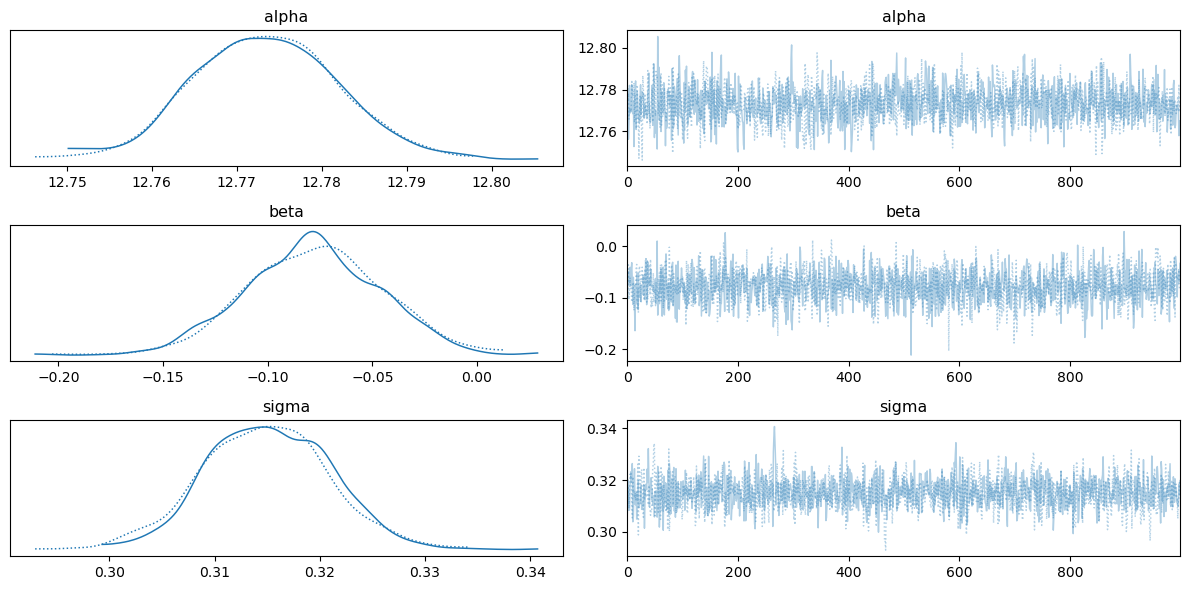

In [86]:
fit_simple_az = az.from_cmdstanpy(posterior=simple_fit)
az.plot_trace(fit_simple_az, var_names=['alpha', 'beta', 'sigma']);
plt.tight_layout()

In [93]:
prior_data = {**simple_data, 'use_likelihood': 0}   # same data, likelihood off
prior_fit = model.sample(data=prior_data, chains=2, seed=6300)

Y_prior = prior_fit.stan_variable('Y_rep')    # shape: (2000 draws, 1509 houses), log scale
prior_dollars = np.exp(Y_prior)               # back to dollars

pcts = [2.5, 25, 50, 75, 97.5]
print("Prior predictive ($):", np.percentile(prior_dollars, pcts).round(-3))
print("Observed ($):        ", np.percentile(filtered_montpelier_data['listed_real_value'], pcts).round(-3))

11:52:44 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:52:46 - cmdstanpy - INFO - CmdStan done processing.



Prior predictive ($): [ 41000. 111000. 168000. 249000. 614000.]
Observed ($):         [190000. 288000. 347000. 425000. 651000.]


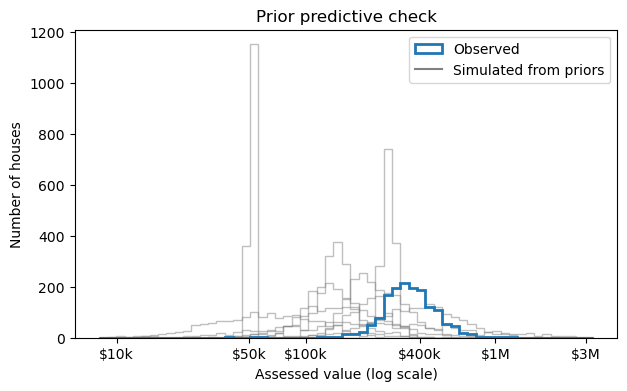

In [97]:
plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)   # log-value range: about $8k to $3.3M

for s in np.random.choice(len(Y_prior), 10, replace=False):
    plt.hist(Y_prior[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from priors')   # legend entry for grey lines
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Prior predictive check')
plt.legend()

Observed min: $38,300
Share of simulated towns with a min that low: 0.000
Observed in-zone sd: 0.373
Share of simulated towns with in-zone sd that large: 0.006


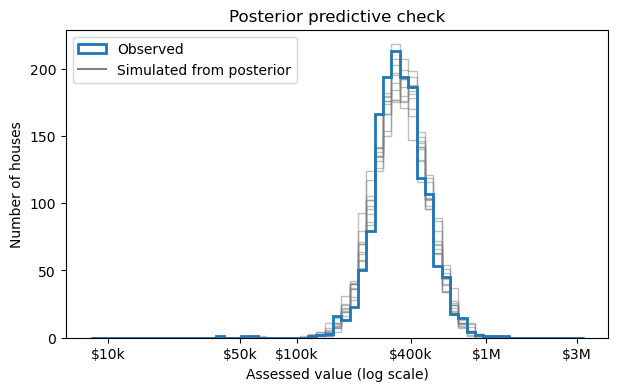

In [99]:
Y_post = simple_fit.stan_variable('Y_rep')   # posterior predictive, log scale

plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)

for s in np.random.choice(len(Y_post), 10, replace=False):
    plt.hist(Y_post[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from posterior')
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Posterior predictive check')
plt.legend()

obs = filtered_montpelier_data['log_value'].values
in_zone = filtered_montpelier_data['in_sfha'].values == 1

# 1. Cheapest house: can the model produce values as low as the real minimum?
sim_min = Y_post.min(axis=1)
print(f"Observed min: ${np.exp(obs.min()):,.0f}")
print(f"Share of simulated towns with a min that low: {(sim_min <= obs.min()).mean():.3f}")

# 2. Spread within the flood zone: does one shared sigma fit the in-zone group?
sim_sd_in = Y_post[:, in_zone].std(axis=1)
print(f"Observed in-zone sd: {obs[in_zone].std():.3f}")
print(f"Share of simulated towns with in-zone sd that large: {(sim_sd_in >= obs[in_zone].std()).mean():.3f}")

# Add lot size for a go at multiple regression

In [101]:
X = np.array(filtered_montpelier_data[['in_sfha', 'log_acres']])  
X[:5]

array([[ 0.        , -1.89711998],
       [ 0.        , -1.10866262],
       [ 0.        , -0.91629073],
       [ 0.        , -1.04982212],
       [ 0.        , -2.65926004]])

In [105]:
multiple_data = {'N': N, 'q': X.shape[1], 'X': X, 'Y': Y, 'use_likelihood': 1}  # 0: prior; 1: posterior
multiple_model = CmdStanModel(stan_file="stan_code/multiple_regression.stan")

multiple_fit = multiple_model.sample(data=multiple_data, chains=2, seed=6300)

12:16:58 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:17:02 - cmdstanpy - INFO - CmdStan done processing.


In [106]:
multiple_fit.summary().loc[['alpha', 'beta[1]', 'beta[2]', 'sigma']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,12.914200,0.000302,0.010854,0.010748,12.896300,12.914100,12.931600,1290.17,1451.67,268.226,1.000890
beta[1],0.026536,0.000740,0.029650,0.029922,-0.020661,0.026341,0.074105,1627.21,1290.48,338.298,1.002130
beta[2],0.141119,0.000205,0.007536,0.007565,0.128863,0.141209,0.153366,1362.54,1271.19,283.273,1.001900
sigma,0.285127,0.000117,0.005225,0.005148,0.276701,0.284960,0.294248,1984.60,1334.02,412.599,0.999885


In [109]:
alpha_multiple = multiple_fit.stan_variable('alpha')
beta_multiple = multiple_fit.stan_variable('beta')
sigma_multiple = multiple_fit.stan_variable('sigma')
mu_multiple = multiple_fit.stan_variable('mu')

alpha_simple = simple_fit.stan_variable('alpha')
beta_simple = simple_fit.stan_variable('beta')
sigma_simple = simple_fit.stan_variable('sigma')
mu_simple = simple_fit.stan_variable('mu')

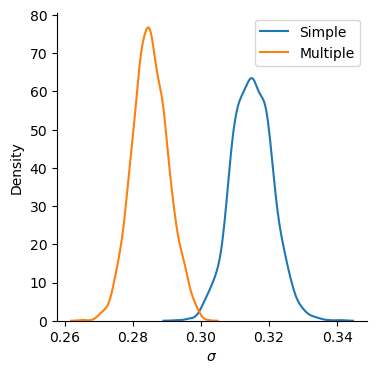

In [110]:
import seaborn as sns
plt.figure(figsize=(4, 4))
sns.kdeplot(sigma_simple, label='Simple')
sns.kdeplot(sigma_multiple, label='Multiple')
plt.xlabel(r'$\sigma$')
plt.ylabel('Density')
sns.despine()
plt.legend()

In [114]:
multiple_prior_data = {'N': N, 'q': X.shape[1], 'X': X, 'Y': Y, 'use_likelihood': 0}  # 0: prior; 1: posterior
multiple_prior_fit = multiple_model.sample(data=multiple_prior_data, chains=2, seed=6300)

Y_prior_multiple = multiple_prior_fit.stan_variable('Y_rep')    # shape: (2000 draws, 1509 houses), log scale
prior_dollars = np.exp(Y_prior_multiple)               # back to dollars

pcts = [2.5, 25, 50, 75, 97.5]
print("Prior predictive ($):", np.percentile(prior_dollars, pcts).round(-3))
print("Observed ($):        ", np.percentile(filtered_montpelier_data['listed_real_value'], pcts).round(-3))

12:35:27 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:35:30 - cmdstanpy - INFO - CmdStan done processing.



Prior predictive ($): [  22000.   90000.  164000.  294000. 1158000.]
Observed ($):         [190000. 288000. 347000. 425000. 651000.]


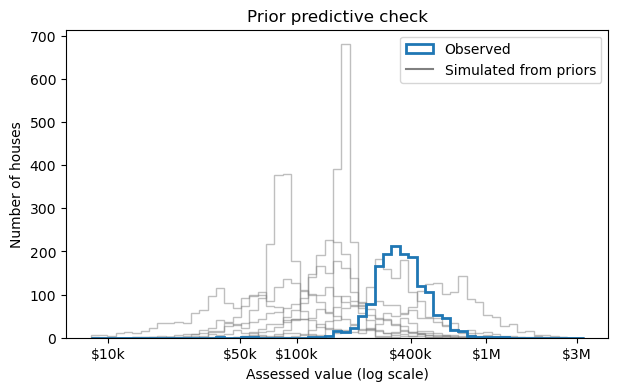

In [115]:
plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)   # log-value range: about $8k to $3.3M

for s in np.random.choice(len(Y_prior_multiple), 10, replace=False):
    plt.hist(Y_prior_multiple[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from priors')   # legend entry for grey lines
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Prior predictive check')
plt.legend()

Observed min: $38,300
Share of simulated towns with a min that low: 0.000
Observed in-zone sd: 0.373
Share of simulated towns with in-zone sd that large: 0.004


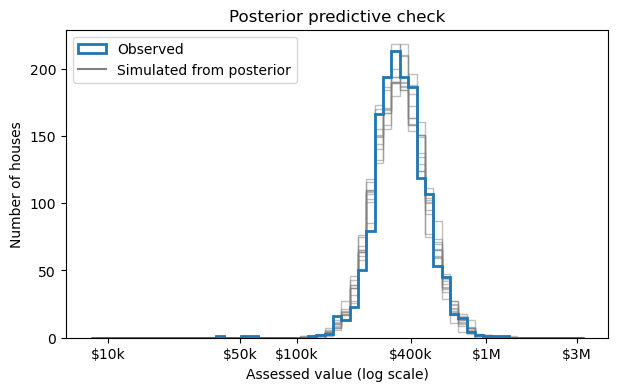

In [116]:
Y_post = multiple_fit.stan_variable('Y_rep')   # posterior predictive, log scale

plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)

for s in np.random.choice(len(Y_post), 10, replace=False):
    plt.hist(Y_post[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from posterior')
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Posterior predictive check')
plt.legend()

obs = filtered_montpelier_data['log_value'].values
in_zone = filtered_montpelier_data['in_sfha'].values == 1

# 1. Cheapest house: can the model produce values as low as the real minimum?
sim_min = Y_post.min(axis=1)
print(f"Observed min: ${np.exp(obs.min()):,.0f}")
print(f"Share of simulated towns with a min that low: {(sim_min <= obs.min()).mean():.3f}")

# 2. Spread within the flood zone: does one shared sigma fit the in-zone group?
sim_sd_in = Y_post[:, in_zone].std(axis=1)
print(f"Observed in-zone sd: {obs[in_zone].std():.3f}")
print(f"Share of simulated towns with in-zone sd that large: {(sim_sd_in >= obs[in_zone].std()).mean():.3f}")